In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor

import xgboost as xgb
import lightgbm as lgb
import catboost as cb

sns.set(style="whitegrid", context="notebook", font_scale=1.1)
start_time = time.time()
print("Libraries imported.")

Libraries imported.


In [2]:
data_folder = "/kaggle/input/march-machine-learning-mania-2025"

# Load men's and women's regular season detailed results and teams
m_reg = pd.read_csv(os.path.join(data_folder, "MRegularSeasonDetailedResults.csv"))
MTeams = pd.read_csv(os.path.join(data_folder, "MTeams.csv"))

w_reg = pd.read_csv(os.path.join(data_folder, "WRegularSeasonDetailedResults.csv"))
WTeams = pd.read_csv(os.path.join(data_folder, "WTeams.csv"))

# Load Massey ratings – assumed to contain columns "Team" and "MAS"
massey_ratings = pd.read_csv("/kaggle/input/massey/Massey Ratings New.csv")

print("Data loaded. (Men’s and Women’s results, teams, and Massey ratings)")

Data loaded. (Men’s and Women’s results, teams, and Massey ratings)


In [3]:
# %% [markdown]
# ## 3. Compute Elo Ratings
# 
# Here we compute a simple Elo rating for each team based on historical game outcomes.
# (For a production system, you’d use a more sophisticated approach.)

# %% [code]
def initialize_elo(team_ids, start_elo=1500):
    return {tid: start_elo for tid in team_ids}

def update_elo(elo_dict, teamA, teamB, scoreA, scoreB, k=20):
    ra = elo_dict[teamA]
    rb = elo_dict[teamB]
    ea = 1.0 / (1 + 10 ** ((rb - ra) / 400))
    sa = 1 if scoreA > scoreB else 0
    # Update ratings
    elo_dict[teamA] = ra + k * (sa - ea)
    elo_dict[teamB] = rb + k * ((1-sa) - (1-ea))
    
def compute_elo(df):
    df_sorted = df.sort_values(by=["Season", "DayNum"])
    teams = np.unique(np.concatenate((df_sorted["WTeamID"].unique(), df_sorted["LTeamID"].unique())))
    elo = initialize_elo(teams)
    for _, row in df_sorted.iterrows():
        update_elo(elo, row["WTeamID"], row["LTeamID"], row["WScore"], row["LScore"])
    return elo

# Compute Elo ratings using all available historical data
elo_m = compute_elo(m_reg)
elo_w = compute_elo(w_reg)
print("Elo ratings computed for men and women.")

Elo ratings computed for men and women.


In [4]:
# %% [markdown]
# ## 4. Compute New Ratings (Adjusted Margins)
# 
# For seasons 2019–2023, we compute a “new rating” for each team based on the average adjusted game margin.
# The adjustment adds a bonus for home games and subtracts it for away games.

# %% [code]
def compute_team_new_rating(df, team_id, bonus=2):
    margins = []
    
    # For games the team won:
    df_win = df[df["WTeamID"] == team_id].copy()
    df_win["adj_margin"] = df_win["WScore"] - df_win["LScore"]
    df_win.loc[df_win["WLoc"] == "H", "adj_margin"] += bonus
    df_win.loc[df_win["WLoc"] == "A", "adj_margin"] -= bonus
    margins.extend(df_win["adj_margin"].tolist())
    
    # For games the team lost:
    df_loss = df[df["LTeamID"] == team_id].copy()
    df_loss["adj_margin"] = -(df_loss["WScore"] - df_loss["LScore"])
    df_loss.loc[df_loss["WLoc"] == "H", "adj_margin"] -= bonus  # losing away
    df_loss.loc[df_loss["WLoc"] == "A", "adj_margin"] += bonus  # losing at home
    margins.extend(df_loss["adj_margin"].tolist())
    
    if len(margins) == 0:
        return np.nan
    return np.mean(margins)

# Filter games from seasons 2019-2023
m_reg_new = m_reg[(m_reg["Season"] >= 2019) & (m_reg["Season"] <= 2024)]
w_reg_new = w_reg[(w_reg["Season"] >= 2019) & (w_reg["Season"] <= 2024)]

team_ids_m = MTeams["TeamID"].unique()
team_ids_w = WTeams["TeamID"].unique()

new_rating_men = {tid: compute_team_new_rating(m_reg_new, tid) for tid in team_ids_m}
new_rating_women = {tid: compute_team_new_rating(w_reg_new, tid) for tid in team_ids_w}
print("New ratings computed for men and women (2019-2023).")

New ratings computed for men and women (2019-2023).


In [5]:
# %% [markdown]
# ## 5. Compute Combined Ratings
# 
# We combine Elo, the new rating, and Massey rating (from the Massey file) using weighted averages.
# **Change:** Instead of using a dummy value of 1500, we now use the actual Elo ratings computed above.
# 
# Also, we map the Massey ratings from the "Massey Ratings New.csv" file to teams based on team names.

# %% [code]
# Create mapping from team name to MAS rating.
massey_mapping = dict(zip(massey_ratings["Team"], massey_ratings["MAS"]))

# Map MAS rating onto teams (assume team names match exactly)
MTeams["CombinedMAS"] = MTeams["TeamName"].map(massey_mapping)
WTeams["CombinedMAS"] = WTeams["TeamName"].map(massey_mapping)

def compute_combined_rating(team_id, gender="M", weight_elo=0.33, weight_new=0.33, weight_massey=0.34):
    if gender == "M":
        rating_elo = elo_m.get(team_id, 1500)
        rating_new = new_rating_men.get(team_id, np.nan)
        mas = MTeams.loc[MTeams["TeamID"] == team_id, "CombinedMAS"]
    else:
        rating_elo = elo_w.get(team_id, 1500)
        rating_new = new_rating_women.get(team_id, np.nan)
        mas = WTeams.loc[WTeams["TeamID"] == team_id, "CombinedMAS"]
    rating_massey = mas.values[0] if not mas.empty else np.nan
    ratings = np.array([rating_elo, rating_new, rating_massey], dtype=float)
    weights = np.array([weight_elo, weight_new, weight_massey])
    valid = ~np.isnan(ratings)
    if valid.sum() == 0:
        return np.nan
    return np.average(ratings[valid], weights=weights[valid])

combined_rating_men = {tid: compute_combined_rating(tid, "M") for tid in team_ids_m}
combined_rating_women = {tid: compute_combined_rating(tid, "W") for tid in team_ids_w}
print("Combined ratings computed for men and women.")

Combined ratings computed for men and women.


In [6]:
# %% [code]
def prepare_model_data(df, gender="M"):
    X, y = [], []
    for _, row in df.iterrows():
        if gender == "M":
            r_w = combined_rating_men.get(row["WTeamID"], np.nan)
            r_l = combined_rating_men.get(row["LTeamID"], np.nan)
        else:
            r_w = combined_rating_women.get(row["WTeamID"], np.nan)
            r_l = combined_rating_women.get(row["LTeamID"], np.nan)
        if np.isnan(r_w) or np.isnan(r_l):
            continue
        X.append([r_w - r_l])
        y.append(row["WScore"] - row["LScore"])
    return np.array(X), np.array(y)

# For men's games:
m_2024 = m_reg
X_m, y_m = prepare_model_data(m_2024, "M")
X_train_m, X_val_m, y_train_m, y_val_m = train_test_split(X_m, y_m, test_size=0.2, random_state=42)

# For women's games:
w_2024 = w_reg
X_w, y_w = prepare_model_data(w_2024, "W")
X_train_w, X_val_w, y_train_w, y_val_w = train_test_split(X_w, y_w, test_size=0.2, random_state=42)

print("Training and validation data prepared for both men and women (from 2024 data).")

Training and validation data prepared for both men and women (from 2024 data).


In [7]:
# %% [code]
from scipy.stats import uniform, randint

models_grid = {
    "LinearRegression": {
        "model": LinearRegression(),
        "params": {}
    },
    "Ridge": {
        "model": Ridge(),
        "params": {"alpha": uniform(0.1, 10)}
    },
    "Lasso": {
        "model": Lasso(max_iter=5000),
        "params": {"alpha": uniform(0.001, 1)}
    },
    "DecisionTree": {
        "model": DecisionTreeRegressor(),
        "params": {"max_depth": randint(1, 10), "min_samples_split": randint(2, 10)}
    },
    "RandomForest": {
        "model": RandomForestRegressor(random_state=42, n_jobs=1),
        "params": {"n_estimators": randint(50, 200), "max_depth": randint(1, 10)}
    },
    "ExtraTrees": {
        "model": ExtraTreesRegressor(random_state=42, n_jobs=1),
        "params": {"n_estimators": randint(50, 200), "max_depth": randint(1, 10)}
    },
    "GradientBoosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {"n_estimators": randint(50, 200), "learning_rate": uniform(0.01, 0.3), "max_depth": randint(1, 10)}
    },
    "XGBoost": {
        "model": xgb.XGBRegressor(tree_method="gpu_hist", random_state=42, n_jobs=1),
        "params": {"n_estimators": randint(50, 200), "learning_rate": uniform(0.01, 0.3), "max_depth": randint(1, 10)}
    },
    "LightGBM": {
        "model": lgb.LGBMRegressor(device="gpu", random_state=42),
        "params": {"n_estimators": randint(50, 200), "learning_rate": uniform(0.01, 0.3), "num_leaves": randint(20, 50)}
    },
    "CatBoost": {
        "model": cb.CatBoostRegressor(task_type="GPU", verbose=0, random_state=42),
        "params": {"iterations": randint(50, 200), "learning_rate": uniform(0.01, 0.3), "depth": randint(3, 10)}
    }
}

def tune_and_evaluate(model_obj, param_dist, X_train, y_train, X_val, y_val):
    rs = RandomizedSearchCV(model_obj, param_distributions=param_dist, 
                              n_iter=10, cv=3, scoring="neg_mean_squared_error", random_state=42,
                              error_score='raise', n_jobs=1)
    rs.fit(X_train, y_train)
    best_model = rs.best_estimator_
    y_pred = best_model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    # Convert margin prediction to win probability (using logistic transform)
    def margin_to_probability(margin, scale=10.0):
        return 1.0 / (1 + 10 ** (-margin/scale))
    pred_prob = margin_to_probability(y_pred, scale=10.0)
    # For validation, since winning team wins, ground truth probability is 1.
    brier = np.mean((pred_prob - 1)**2)
    return best_model, rmse, brier

# Tune men's models.
men_results = {}
men_best_models = {}
print("Tuning Men's models:")
for name, info in models_grid.items():
    try:
        best_model, rmse, brier = tune_and_evaluate(info["model"], info["params"],
                                                    X_train_m, y_train_m, X_val_m, y_val_m)
        men_results[name] = {"rmse": rmse, "brier": brier}
        men_best_models[name] = best_model
        print(f"Men's {name}: RMSE = {rmse:.4f}, Brier = {brier:.4f}")
    except Exception as e:
        print(f"Tuning men's {name} failed: {e}")

# Tune women's models.
women_results = {}
women_best_models = {}
print("\nTuning Women's models:")
for name, info in models_grid.items():
    try:
        best_model, rmse, brier = tune_and_evaluate(info["model"], info["params"],
                                                    X_train_w, y_train_w, X_val_w, y_val_w)
        women_results[name] = {"rmse": rmse, "brier": brier}
        women_best_models[name] = best_model
        print(f"Women's {name}: RMSE = {rmse:.4f}, Brier = {brier:.4f}")
    except Exception as e:
        print(f"Tuning women's {name} failed: {e}")

print("\nMen's Model Results:")
print(men_results)
print("\nWomen's Model Results:")
print(women_results)

Tuning Men's models:
Men's LinearRegression: RMSE = 9.0538, Brier = 0.0067


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:305: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Men's Ridge: RMSE = 9.0538, Brier = 0.0067
Men's Lasso: RMSE = 9.0537, Brier = 0.0067
Men's DecisionTree: RMSE = 8.6767, Brier = 0.0058
Men's RandomForest: RMSE = 8.6547, Brier = 0.0058
Men's ExtraTrees: RMSE = 8.6965, Brier = 0.0049
Men's GradientBoosting: RMSE = 8.6538, Brier = 0.0058


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [02:09:47] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [02:09:47] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [02:09:48] WARNING: /workspace/src

Men's XGBoost: RMSE = 8.6959, Brier = 0.0057
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 63403, number of used features: 1
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 1 dense feature groups (0.24 MB) transferred to GPU in 0.002738 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score 11.963519
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 63403, number of used features: 1
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entr

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:305: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Women's Lasso: RMSE = 10.6927, Brier = 0.0031
Women's DecisionTree: RMSE = 10.5600, Brier = 0.0022
Women's RandomForest: RMSE = 10.4973, Brier = 0.0023
Women's ExtraTrees: RMSE = 10.5549, Brier = 0.0021
Women's GradientBoosting: RMSE = 10.3987, Brier = 0.0025


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [02:15:25] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [02:15:26] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [02:15:26] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserW

Women's XGBoost: RMSE = 10.5684, Brier = 0.0022
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 43577, number of used features: 1
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 1 dense feature groups (0.17 MB) transferred to GPU in 0.000552 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score 14.400257
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 43577, number of used features: 1
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin e

In [8]:
# %% [code]
# Men's validation predictions.
val_preds_m = pd.DataFrame({"ID": np.arange(len(X_val_m))})
for name, model in men_best_models.items():
    val_preds_m[name] = model.predict(X_val_m)

# Women's validation predictions.
val_preds_w = pd.DataFrame({"ID": np.arange(len(X_val_w))})
for name, model in women_best_models.items():
    val_preds_w[name] = model.predict(X_val_w)

print("Validation predictions generated for both men and women.")

Validation predictions generated for both men and women.


In [9]:
# %% [code]
df_sub = pd.read_csv(os.path.join(data_folder, "SampleSubmissionStage2.csv"))

# Parse the ID field to extract Season, Team1, and Team2.
def parse_id(match_id):
    season, t1, t2 = match_id.split('_')
    return int(season), int(t1), int(t2)

df_sub["Season"] = df_sub["ID"].apply(lambda x: parse_id(x)[0])
df_sub["Team1"] = df_sub["ID"].apply(lambda x: parse_id(x)[1])
df_sub["Team2"] = df_sub["ID"].apply(lambda x: parse_id(x)[2])
print("Submission file loaded and parsed for 2025.")

Submission file loaded and parsed for 2025.


In [10]:
# %% [code]
def predict_match(row, men_model_name, women_model_name):
    s = row["Season"]
    t1 = row["Team1"]
    t2 = row["Team2"]
    if t1 < 2000 and t2 < 2000:
        diff = combined_rating_men.get(t1, 1500) - combined_rating_men.get(t2, 1500)
        pred = men_best_models[men_model_name].predict(np.array([[diff]]))[0]
    elif t1 >= 3000 and t2 >= 3000:
        diff = combined_rating_women.get(t1, 1500) - combined_rating_women.get(t2, 1500)
        pred = women_best_models[women_model_name].predict(np.array([[diff]]))[0]
    else:
        pred = 0.5
    return pred

submission_folder = "combined_submissions"
os.makedirs(submission_folder, exist_ok=True)
combined_submission_files = []

for m_name in men_best_models.keys():
    for w_name in women_best_models.keys():
        df_sub["Pred"] = df_sub.apply(lambda row: predict_match(row, m_name, w_name), axis=1)
        fname = os.path.join(submission_folder, f"submission_{m_name}_{w_name}.csv")
        df_sub[["ID", "Pred"]].to_csv(fname, index=False)
        combined_submission_files.append(fname)
        print(f"Saved submission file: {fname}")

Saved submission file: combined_submissions/submission_LinearRegression_LinearRegression.csv
Saved submission file: combined_submissions/submission_LinearRegression_Ridge.csv
Saved submission file: combined_submissions/submission_LinearRegression_Lasso.csv
Saved submission file: combined_submissions/submission_LinearRegression_DecisionTree.csv
Saved submission file: combined_submissions/submission_LinearRegression_RandomForest.csv
Saved submission file: combined_submissions/submission_LinearRegression_ExtraTrees.csv
Saved submission file: combined_submissions/submission_LinearRegression_GradientBoosting.csv
Saved submission file: combined_submissions/submission_LinearRegression_XGBoost.csv
Saved submission file: combined_submissions/submission_LinearRegression_LightGBM.csv
Saved submission file: combined_submissions/submission_LinearRegression_CatBoost.csv
Saved submission file: combined_submissions/submission_Ridge_LinearRegression.csv
Saved submission file: combined_submissions/submi

Ensemble performance on combined predictions:
   Ensemble    Method       RMSE     Brier
0      top2    simple  12.652137  0.005415
1      top2  weighted  12.652137  0.005415
2      top3    simple  12.652213  0.005334
3      top3  weighted  12.652212  0.005334
4      top5    simple  12.642209  0.005244
5      top5  weighted  12.642215  0.005244
6      top7    simple  12.618168  0.005133
7      top7  weighted  12.618190  0.005133
8      top9    simple  12.553425  0.005086
9      top9  weighted  12.553614  0.005086
10    top11    simple  12.517044  0.005034
11    top11  weighted  12.517311  0.005034


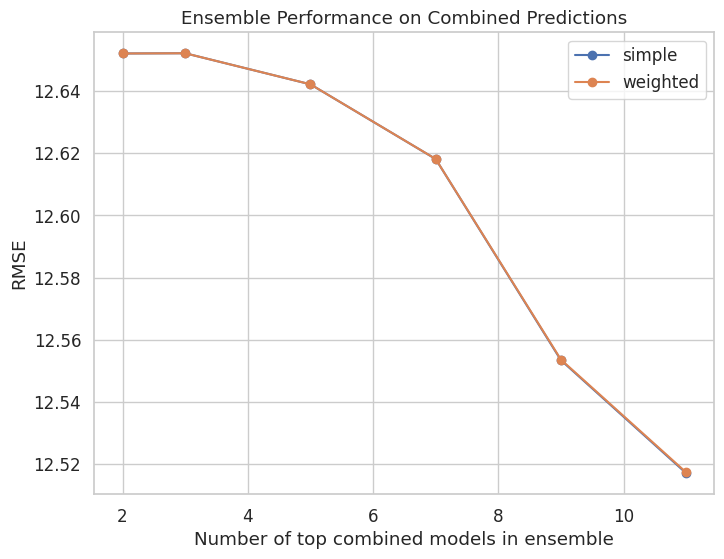

In [11]:
# %% [code]
def margin_to_probability(margin, scale=10.0):
    return 1.0 / (1 + 10 ** (-margin/scale))

def compute_ensemble_scores(pred_df, y_true, model_list, method="simple", combined_rmse_dict=None, scale=10.0):
    if method == "simple":
        ens_margin = pred_df[model_list].mean(axis=1)
    elif method == "weighted":
        weights = np.array([1/combined_rmse_dict[m] for m in model_list])
        weights = weights / np.sum(weights)
        ens_margin = np.sum(pred_df[model_list].values * weights, axis=1)
    else:
        raise ValueError("Method not supported.")
    rmse = np.sqrt(mean_squared_error(y_true, ens_margin))
    ens_prob = margin_to_probability(ens_margin, scale=scale)
    # In our dummy validation, assume the winning team wins (true probability=1).
    brier = np.mean((ens_prob - 1)**2)
    return rmse, brier

# **** For ensemble evaluation, we simulate a combined predictions DataFrame
# Here we load all combined submission files and merge by "ID" order.
combined_preds_df = pd.DataFrame()
for fname in combined_submission_files:
    temp = pd.read_csv(fname)
    col_name = os.path.basename(fname).replace("submission_", "").replace(".csv", "")
    combined_preds_df[col_name] = temp["Pred"]

# Dummy true values for evaluation: for validation, assume winning margin > 0 corresponds to win (i.e. probability 1).
dummy_true = np.ones(len(combined_preds_df))

# Create a combined RMSE dictionary by averaging the men's and women's RMSE from tuning.
combined_rmse_dict = {}
for m in men_results:
    for w in women_results:
        key = f"{m}_{w}"
        combined_rmse_dict[key] = (men_results[m]["rmse"] + women_results[w]["rmse"]) / 2

sorted_combined = sorted(combined_rmse_dict.items(), key=lambda x: x[1])
sorted_combined_names = [x[0] for x in sorted_combined]

ensemble_sizes = [2, 3, 5, 7, 9, 11]
ensemble_results = []
for size in ensemble_sizes:
    models_used = sorted_combined_names[:size]
    rmse_simple, brier_simple = compute_ensemble_scores(combined_preds_df, dummy_true, models_used, method="simple", scale=10.0)
    rmse_weighted, brier_weighted = compute_ensemble_scores(combined_preds_df, dummy_true, models_used, method="weighted", combined_rmse_dict=combined_rmse_dict, scale=10.0)
    ensemble_results.append({
        "Ensemble": f"top{size}",
        "Method": "simple",
        "RMSE": rmse_simple,
        "Brier": brier_simple
    })
    ensemble_results.append({
        "Ensemble": f"top{size}",
        "Method": "weighted",
        "RMSE": rmse_weighted,
        "Brier": brier_weighted
    })

ensemble_scores_df = pd.DataFrame(ensemble_results)
print("Ensemble performance on combined predictions:")
print(ensemble_scores_df)

plt.figure(figsize=(8,6))
for method in ["simple", "weighted"]:
    subset = ensemble_scores_df[ensemble_scores_df["Method"]==method]
    sizes = [int(x.replace("top","")) for x in subset["Ensemble"]]
    plt.plot(sizes, subset["RMSE"], marker='o', label=method)
plt.xlabel("Number of top combined models in ensemble")
plt.ylabel("RMSE")
plt.title("Ensemble Performance on Combined Predictions")
plt.legend()
plt.show()

In [12]:
# %% [code]
# Decide on the best ensemble: using top9 models with a simple (arithmetic) average.
best_ensemble = sorted_combined_names[:9]
print("Best ensemble models (simple, top9):", best_ensemble)

# Compute final predictions using simple average (arithmetic mean)
final_preds = combined_preds_df[best_ensemble].mean(axis=1)

# Load the actual 2025 test submission file.
df_sub_test = pd.read_csv(os.path.join(data_folder, "SampleSubmissionStage2.csv"))
# Parse the "ID" field to extract Season, Team1, and Team2.
df_sub_test["Season"] = df_sub_test["ID"].apply(lambda x: parse_id(x)[0])
df_sub_test["Team1"] = df_sub_test["ID"].apply(lambda x: parse_id(x)[1])
df_sub_test["Team2"] = df_sub_test["ID"].apply(lambda x: parse_id(x)[2])
df_sub_test["Pred"] = final_preds

# Save final submission as "submission.csv"
submission_filename = "submission.csv"
df_sub_test[["ID", "Pred"]].to_csv(submission_filename, index=False)
print(f"Final submission saved as {submission_filename}")

Best ensemble models (simple, top9): ['GradientBoosting_GradientBoosting', 'RandomForest_GradientBoosting', 'DecisionTree_GradientBoosting', 'XGBoost_GradientBoosting', 'LightGBM_GradientBoosting', 'ExtraTrees_GradientBoosting', 'CatBoost_GradientBoosting', 'GradientBoosting_RandomForest', 'RandomForest_RandomForest']
Final submission saved as submission.csv
